# 4.5.2. Реальные рыночные данные: exact / heuristic / SB baselines


Идея: если `SB` не находит ни одной пары, это ещё не означает, что в real market graph нет кандидатов. Поэтому сначала строим независимые baseline-решения:

1. **MILP / HiGHS** - exact baseline для dummy-cycle / optimal path;
2. **Simulated Annealing** - классическая эвристика, работающая напрямую в пространстве валидных путей;
3. **SB quality mode** - QUBO -> Ising -> SB -> post-verification;
4. дополнительная диагностика **SB with cost rescaling**, потому что реальные веса после нормировки малы по абсолютной величине.

Разделы 4.2–4.4 здесь не пересматриваются. Используются уже зафиксированные параметры для QUBO-cycle quality mode:

```text
mc = 1
mp = 1
dt = 0.5
n_iter = 500
n_runs = 100
```

## 1. Инициализация путей и импортов

In [1]:
from __future__ import annotations

import math
import sys
import time
import json
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
OUT_DIR = CWD / "04_05"

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", CWD)
print("OUT_DIR:", OUT_DIR)

PROJECT_ROOT: C:\Users\Антон\Desktop\курсовая
OUT_DIR: C:\Users\Антон\Desktop\курсовая\04_05


## 2. Импорт проектных модулей

Используются уже проверенные модули: QUBO construction, QUBO-Ising mapping, SB solvers и post-verification dummy-cycle.

In [2]:
from scipy.optimize import milp, LinearConstraint, Bounds
sys.path.append('курсовая_2')
from qubo_cycle import build_cycle_qubo
from ising_mapping import qubo_to_ising
from SB_modules import BSB, DSB
from pair_search import (
    CycleSolution,
    TabuList,
    verify_single_dummy_cycle,
    extract_pair_and_weight,
    _decode_edges,
)

## 3. Конфигурация эксперимента

`THRESHOLD = -0.01` выбран как стартовый рабочий порог: он достаточно строгий, но не отбрасывает все реальные отрицательные кандидаты из `04_05_01`.

`SB_COST_SCALE` не используется в основном SB quality mode. Это отдельная диагностическая проверка: реальные веса порядка `10^{-2}`, поэтому для Python/SB полезно проверить, не исчезает ли сигнал относительно penalty landscape.

In [3]:

THRESHOLD = -0.01
MAX_PAIRS = 10
RUN_SEQUENTIAL_COMPARISON = True  # set True for full sequential tabu experiment
SEED = 20260609

MC = 1.0
MP = 1.0
DT = 0.5
N_ITER = 500
N_RUNS = 100
SB_VARIANT = "BSB"

# SA parameters
SA_RESTARTS = 25
SA_STEPS = 1200

# MILP time limit per call.
MILP_TIME_LIMIT = 60.0

USE_SB_SCALED_DIAGNOSTIC = True
SB_COST_SCALE = None

CONFIG = {
    "threshold": THRESHOLD,
    "max_pairs": MAX_PAIRS,
    "run_sequential_comparison": RUN_SEQUENTIAL_COMPARISON,
    "mc": MC,
    "mp": MP,
    "dt": DT,
    "n_iter": N_ITER,
    "n_runs": N_RUNS,
    "sb_variant": SB_VARIANT,
    "sa_restarts": SA_RESTARTS,
    "sa_steps": SA_STEPS,
    "milp_time_limit": MILP_TIME_LIMIT,
    "use_sb_scaled_diagnostic": USE_SB_SCALED_DIAGNOSTIC,
    "seed": SEED,
}
CONFIG

{'threshold': -0.01,
 'max_pairs': 10,
 'run_sequential_comparison': True,
 'mc': 1.0,
 'mp': 1.0,
 'dt': 0.5,
 'n_iter': 500,
 'n_runs': 100,
 'sb_variant': 'BSB',
 'sa_restarts': 25,
 'sa_steps': 1200,
 'milp_time_limit': 60.0,
 'use_sb_scaled_diagnostic': True,
 'seed': 20260609}

## 4. Загрузка артефактов `04_05_01`

Минимально нужны:

- `real_data_market_weights_04_05_01.csv`;
- `real_data_quotes_04_05_01.csv`;
- `real_data_edges_ranked_04_05_01.csv`.

Файлы ищутся сначала в `04_05`, затем в корне проекта. Это сделано, чтобы тетрадка работала и после ручной загрузки CSV в корень.

In [5]:
weights_path = "04_05/real_data_market_weights_04_05_01.csv"
quotes_path = "04_05/real_data_quotes_04_05_01.csv"
edges_ranked_path = "04_05/real_data_edges_ranked_04_05_01.csv"

graph_diag_path = "04_05/real_data_graph_diagnostics_04_05_01.csv"


weights_df = pd.read_csv(weights_path, index_col=0)
quotes_df = pd.read_csv(quotes_path)
edges_ranked_df = pd.read_csv(edges_ranked_path)

graph_diag_df = pd.read_csv(graph_diag_path)

labels = list(weights_df.index)
w_raw = weights_df.values.astype(float)
N = w_raw.shape[0] - 1
node_to_symbol = {i: labels[i] for i in range(N + 1)}
symbol_to_node = {v: k for k, v in node_to_symbol.items()}

assert labels[0].upper() == "DUMMY", "Ожидался dummy node в первой строке/колонке"
assert w_raw.shape == (N + 1, N + 1)
assert np.allclose(w_raw[0, :], 0.0)
assert np.allclose(w_raw[:, 0], 0.0)

stock_w = w_raw[1:, 1:]
max_abs_stock_weight = float(np.max(np.abs(stock_w)))
if SB_COST_SCALE is None:
    SB_COST_SCALE = 1.0 / max(max_abs_stock_weight, 1e-12)

print("N assets:", N)
print("max_abs_stock_weight:", max_abs_stock_weight)
print("SB_COST_SCALE:", SB_COST_SCALE)

quotes_df.head()

N assets: 15
max_abs_stock_weight: 0.0269822518707688
SB_COST_SCALE: 37.06139890730726


,symbol,valuation_day_utc,base_open,bid_raw,ask_raw,bid_norm,ask_norm,spread_raw,spread_norm
0,BTCUSDT,20260609,63086.0000,61986.0000,61986.0100,0.982563,0.982564,0.0100,1.585138e-07
1,ETHUSDT,20260609,1690.4800,1654.5100,1654.5200,0.978722,0.978728,0.0100,5.915480e-06
2,BNBUSDT,20260609,601.8600,596.0800,596.0900,0.990396,0.990413,0.0100,1.661516e-05
3,SOLUSDT,20260609,66.8200,65.4700,65.4800,0.979796,0.979946,0.0100,1.496558e-04
4,XRPUSDT,20260609,1.1683,1.1447,1.1448,0.979800,0.979885,0.0001,8.559445e-05


## 5. Threshold diagnostics на уровне direct edges

Сначала проверяем, есть ли вообще отрицательные directed edges до учёта bypass paths. Это не является финальным solver-result, но помогает понять масштаб задачи.

In [5]:
threshold_diagnostics = []
for thr in [0.0, -0.005, -0.01, -0.02, -0.03]:
    threshold_diagnostics.append({
        "threshold": thr,
        "n_direct_edges_below_threshold": int((edges_ranked_df["weight"] < thr).sum()),
        "share_direct_edges_below_threshold": float((edges_ranked_df["weight"] < thr).mean()),
    })

threshold_diagnostics_df = pd.DataFrame(threshold_diagnostics)
threshold_diagnostics_df.to_csv(OUT_DIR / "real_market_threshold_diagnostics_04_05_02.csv", index=False)

display(threshold_diagnostics_df)
display(edges_ranked_df.head(10))

,threshold,n_direct_edges_below_threshold,share_direct_edges_below_threshold
0,0.000,100,0.476190
1,-0.005,47,0.223810
2,-0.010,25,0.119048
3,-0.020,7,0.033333
4,-0.030,0,0.000000


,short_node,long_node,short_symbol,long_symbol,similarity,bid_norm_short,ask_norm_long,ask_minus_bid_norm,weight
0,12,5,LTCUSDT,XRPUSDT,0.891797,1.009761,0.979885,-0.029875,-0.026643
1,12,4,LTCUSDT,SOLUSDT,0.893554,1.009761,0.979946,-0.029815,-0.026641
2,12,2,LTCUSDT,ETHUSDT,0.805923,1.009761,0.978728,-0.031033,-0.025010
3,14,4,ATOMUSDT,SOLUSDT,0.903604,1.007365,0.979946,-0.027419,-0.024776
4,12,1,LTCUSDT,BTCUSDT,0.908483,1.009761,0.982564,-0.027197,-0.024708
5,14,5,ATOMUSDT,XRPUSDT,0.884130,1.007365,0.979885,-0.027480,-0.024296
6,14,2,ATOMUSDT,ETHUSDT,0.847594,1.007365,0.978728,-0.028638,-0.024273
7,12,7,LTCUSDT,DOGEUSDT,0.858106,1.009761,0.986798,-0.022963,-0.019704
8,12,9,LTCUSDT,LINKUSDT,0.793834,1.009761,0.985119,-0.024641,-0.019561
9,14,9,ATOMUSDT,LINKUSDT,0.858277,1.007365,0.985119,-0.022246,-0.019093


## 6. Общие функции для представления решения

Все solver-результаты приводятся к единому формату: endpoints, path, raw `path_weight`, direct edge weight и признак bypass path.

In [6]:
Edge = Tuple[int, int]
Path = List[int]
ForbiddenPair = Tuple[int, int]  # (short, long)


def path_weight(path: Sequence[int], w: np.ndarray = w_raw) -> float:
    return float(sum(w[a, b] for a, b in zip(path[:-1], path[1:])))


def path_to_cycle_edges(path: Sequence[int]) -> List[Edge]:
    return [(0, int(path[0]))] + [(int(a), int(b)) for a, b in zip(path[:-1], path[1:])] + [(int(path[-1]), 0)]


def make_solution_record(
    solver: str,
    iteration: int,
    path: Optional[Sequence[int]],
    runtime_sec: float,
    status: str = "ok",
    extra: Optional[Dict] = None,
) -> Dict:
    extra = {} if extra is None else dict(extra)
    if path is None or len(path) < 2:
        rec = {
            "solver": solver,
            "iteration": iteration,
            "status": status,
            "accepted": False,
            "short_node": None,
            "long_node": None,
            "short_symbol": None,
            "long_symbol": None,
            "path_nodes": None,
            "path_symbols": None,
            "path_length_assets": 0,
            "path_weight": np.nan,
            "direct_weight": np.nan,
            "is_bypass": None,
            "threshold": THRESHOLD,
            "runtime_sec": runtime_sec,
        }
        rec.update(extra)
        return rec

    path = [int(x) for x in path]
    short, long = path[0], path[-1]
    pw = path_weight(path, w_raw)
    direct_w = float(w_raw[short, long])
    rec = {
        "solver": solver,
        "iteration": iteration,
        "status": status,
        "accepted": bool(pw < THRESHOLD),
        "short_node": short,
        "long_node": long,
        "short_symbol": node_to_symbol[short],
        "long_symbol": node_to_symbol[long],
        "path_nodes": "->".join(map(str, path)),
        "path_symbols": "->".join(node_to_symbol[i] for i in path),
        "path_length_assets": len(path),
        "path_weight": pw,
        "direct_weight": direct_w,
        "is_bypass": bool(len(path) > 2),
        "threshold": THRESHOLD,
        "runtime_sec": runtime_sec,
    }
    rec.update(extra)
    return rec


def print_solution(rec: Dict):
    print(f"{rec['solver']} | iter={rec['iteration']} | status={rec['status']} | accepted={rec['accepted']}")
    if rec.get("path_symbols"):
        print("  path:", rec["path_symbols"])
        print("  weight:", rec["path_weight"], "direct:", rec["direct_weight"], "bypass:", rec["is_bypass"])

## 7. MILP / HiGHS exact baseline

In [7]:
def solve_milp_cycle(
    w: np.ndarray,
    forbidden_pairs: Optional[Sequence[ForbiddenPair]] = None,
    time_limit: float = MILP_TIME_LIMIT,
) -> Dict:
    """Solve dummy-cycle optimal path by MILP/HiGHS and return unified diagnostic dict."""
    forbidden_pairs = [] if forbidden_pairs is None else list(forbidden_pairs)
    Nloc = w.shape[0] - 1
    nodes = list(range(Nloc + 1))
    edges = [(i, j) for i in nodes for j in nodes if i != j]
    e2u = {e: k for k, e in enumerate(edges)}
    M = len(edges)
    nvars = M + Nloc  # b_ij plus MTZ order variables u_i for stocks

    c = np.concatenate([np.array([w[i, j] for i, j in edges], dtype=float), np.zeros(Nloc)])
    rows, lb, ub = [], [], []

    # dummy out-degree = 1
    r = np.zeros(nvars)
    for j in range(1, Nloc + 1):
        r[e2u[(0, j)]] = 1.0
    rows.append(r); lb.append(1.0); ub.append(1.0)

    # dummy in-degree = 1
    r = np.zeros(nvars)
    for i in range(1, Nloc + 1):
        r[e2u[(i, 0)]] = 1.0
    rows.append(r); lb.append(1.0); ub.append(1.0)

    # stock degree and flow balance
    for i in range(1, Nloc + 1):
        # out_i <= 1
        r = np.zeros(nvars)
        for j in nodes:
            if j != i:
                r[e2u[(i, j)]] = 1.0
        rows.append(r); lb.append(0.0); ub.append(1.0)

        # in_i <= 1
        r = np.zeros(nvars)
        for j in nodes:
            if j != i:
                r[e2u[(j, i)]] = 1.0
        rows.append(r); lb.append(0.0); ub.append(1.0)

        # out_i - in_i = 0
        r = np.zeros(nvars)
        for j in nodes:
            if j != i:
                r[e2u[(i, j)]] += 1.0
                r[e2u[(j, i)]] -= 1.0
        rows.append(r); lb.append(0.0); ub.append(0.0)

    # no antiparallel pair. For dummy this also forbids trivial 0->a->0.
    for i in nodes:
        for j in range(i + 1, Nloc + 1):
            r = np.zeros(nvars)
            r[e2u[(i, j)]] = 1.0
            r[e2u[(j, i)]] = 1.0
            rows.append(r); lb.append(0.0); ub.append(1.0)

    # tabu endpoint constraints: forbid b_{0,short}=1 and b_{long,0}=1 simultaneously.
    for short, long in forbidden_pairs:
        r = np.zeros(nvars)
        r[e2u[(0, int(short))]] = 1.0
        r[e2u[(int(long), 0)]] = 1.0
        rows.append(r); lb.append(0.0); ub.append(1.0)

    # MTZ subtour elimination for stock-stock arcs.
    # If b_ij = 1, then u_j >= u_i + 1.
    for i in range(1, Nloc + 1):
        for j in range(1, Nloc + 1):
            if i == j:
                continue
            r = np.zeros(nvars)
            r[M + i - 1] = 1.0
            r[M + j - 1] = -1.0
            r[e2u[(i, j)]] = float(Nloc)
            rows.append(r); lb.append(-np.inf); ub.append(float(Nloc - 1))

    A = np.vstack(rows)
    constraints = LinearConstraint(A, np.array(lb), np.array(ub))
    bounds = Bounds(
        np.concatenate([np.zeros(M), np.zeros(Nloc)]),
        np.concatenate([np.ones(M), np.full(Nloc, Nloc)]),
    )
    integrality = np.concatenate([np.ones(M), np.zeros(Nloc)])

    t0 = time.perf_counter()
    res = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={"time_limit": time_limit},
    )
    runtime = time.perf_counter() - t0

    out = {
        "success": bool(res.success),
        "status": int(res.status),
        "message": str(res.message),
        "fun": float(res.fun) if res.fun is not None else np.nan,
        "runtime_sec": runtime,
        "selected_edges": [],
        "cycle": None,
        "path": None,
        "ok_cycle": False,
    }
    if not res.success or res.x is None:
        return out

    z = np.rint(res.x[:M]).astype(int)
    selected_edges = [e for bit, e in zip(z, edges) if bit == 1]
    ok, cycle = verify_single_dummy_cycle(selected_edges, Nloc)
    out["selected_edges"] = selected_edges
    out["cycle"] = cycle
    out["ok_cycle"] = bool(ok)
    if ok and cycle is not None:
        short, long, path, pw = extract_pair_and_weight(cycle, w)
        out["path"] = path
        out["path_weight"] = float(pw)
        out["short"] = int(short)
        out["long"] = int(long)
    return out

## 8. Simulated Annealing baseline в пространстве валидных путей

SA здесь не решает QUBO. Он напрямую изменяет валидный путь `short -> ... -> long`, поэтому всегда возвращает структурно допустимого кандидата. Это важно для диагностики: если SA находит путь ниже threshold, а SB нет, проблема лежит в QUBO/SB search landscape, а не в отсутствии рыночного сигнала.

In [8]:
def random_valid_path(rng: np.random.Generator, forbidden_pairs: set[ForbiddenPair]) -> Path:
    for _ in range(10_000):
        L = int(rng.integers(2, N + 1))
        path = [int(x) for x in rng.choice(np.arange(1, N + 1), size=L, replace=False)]
        if (path[0], path[-1]) not in forbidden_pairs:
            return path
    raise RuntimeError("Could not generate a non-tabu path")


def propose_neighbor(path: Path, rng: np.random.Generator, forbidden_pairs: set[ForbiddenPair]) -> Path:
    path = list(path)
    used = set(path)
    ops = ["replace", "insert", "delete", "change_endpoint", "swap_internal"]
    probs = [0.30, 0.25, 0.20, 0.15, 0.10]
    op = str(rng.choice(ops, p=probs))

    if op == "insert" and len(path) < N:
        candidates = [i for i in range(1, N + 1) if i not in used]
        if not candidates:
            return path
        v = int(rng.choice(candidates))
        pos = int(rng.integers(1, len(path)))
        new = path[:pos] + [v] + path[pos:]

    elif op == "delete" and len(path) > 2:
        pos = int(rng.integers(1, len(path) - 1))
        new = path[:pos] + path[pos + 1:]

    elif op == "change_endpoint":
        candidates = [i for i in range(1, N + 1) if i not in used]
        if not candidates:
            return path
        v = int(rng.choice(candidates))
        new = path.copy()
        if rng.random() < 0.5:
            new[0] = v
        else:
            new[-1] = v

    elif op == "swap_internal" and len(path) > 3:
        a, b = rng.choice(np.arange(1, len(path) - 1), size=2, replace=False)
        new = path.copy()
        new[int(a)], new[int(b)] = new[int(b)], new[int(a)]

    else:
        candidates = [i for i in range(1, N + 1) if i not in used]
        if not candidates:
            return path
        pos = int(rng.integers(0, len(path)))
        v = int(rng.choice(candidates))
        new = path.copy()
        new[pos] = v

    if len(new) < 2 or len(set(new)) != len(new):
        return path
    if (new[0], new[-1]) in forbidden_pairs:
        return path
    return new


def solve_sa_path(
    forbidden_pairs: Optional[Sequence[ForbiddenPair]] = None,
    seed: int = SEED,
    n_restarts: int = SA_RESTARTS,
    n_steps: int = SA_STEPS,
) -> Dict:
    forbidden = set() if forbidden_pairs is None else set((int(a), int(b)) for a, b in forbidden_pairs)
    rng = np.random.default_rng(seed)
    scale = max(1e-9, float(np.std(w_raw[1:, 1:])))
    T0 = 5.0 * scale
    T1 = 0.05 * scale

    best_path = None
    best_weight = float("inf")
    accepted_moves = 0
    proposed_moves = 0

    t0 = time.perf_counter()
    for _ in range(n_restarts):
        cur = random_valid_path(rng, forbidden)
        cur_w = path_weight(cur, w_raw)
        if cur_w < best_weight:
            best_path, best_weight = cur.copy(), cur_w

        for step in range(n_steps):
            temp = T0 * (T1 / T0) ** (step / max(1, n_steps - 1))
            new = propose_neighbor(cur, rng, forbidden)
            new_w = path_weight(new, w_raw)
            delta = new_w - cur_w
            proposed_moves += 1
            if delta <= 0 or rng.random() < math.exp(-delta / max(temp, 1e-12)):
                cur, cur_w = new, new_w
                accepted_moves += 1
                if cur_w < best_weight:
                    best_path, best_weight = cur.copy(), cur_w

    runtime = time.perf_counter() - t0
    return {
        "path": best_path,
        "path_weight": float(best_weight),
        "runtime_sec": runtime,
        "accepted_moves": int(accepted_moves),
        "proposed_moves": int(proposed_moves),
        "acceptance_rate": float(accepted_moves / max(1, proposed_moves)),
    }

## 9. SB quality mode и диагностика valid-cycle rate

SB работает через QUBO/Ising и затем проходит post-verification. Поэтому для SB сохраняем не только лучший валидный путь, но и все run-level результаты: число выбранных рёбер, факт валидности, raw path weight.

Важная диагностика: если `n_selected_edges = 0` почти во всех запусках, SB застревает в нулевой QUBO-конфигурации. Для real-data weights это возможно, потому что отрицательные веса имеют малый абсолютный масштаб.

In [9]:
def make_tabu_from_forbidden(forbidden_pairs: Optional[Sequence[ForbiddenPair]]) -> TabuList:
    tabu = TabuList(N)
    if forbidden_pairs is not None:
        for short, long in forbidden_pairs:
            tabu.forbid(int(short), int(long))
    return tabu


def run_sb_search(
    w_for_qubo: np.ndarray,
    solver_name: str,
    forbidden_pairs: Optional[Sequence[ForbiddenPair]] = None,
    seed: int = SEED,
    n_runs: int = N_RUNS,
    n_iter: int = N_ITER,
    dt: float = DT,
    mc: float = MC,
    mp: float = MP,
    sb_variant: str = SB_VARIANT,
) -> Dict:
    tabu = make_tabu_from_forbidden(forbidden_pairs)
    lin, quad, var_map = build_cycle_qubo(w_for_qubo, tabu=tabu.T, mc=mc, mp=mp)
    J, h, _ = qubo_to_ising(lin, quad)

    run_rows = []
    best_path = None
    best_weight = float("inf")
    best_cycle = None
    best_edges = None

    t0 = time.perf_counter()
    for r in range(n_runs):
        run_seed = int(seed + r)
        if sb_variant.upper() == "BSB":
            solver = BSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        elif sb_variant.upper() == "DSB":
            solver = DSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        else:
            raise ValueError("sb_variant must be 'BSB' or 'DSB'")

        solver.run(record_trajectory=False)
        x = solver.x.reshape(-1)
        s = np.where(x >= 0.0, 1, -1)
        z = ((s + 1) // 2).astype(int)
        selected_edges = _decode_edges(z, var_map)

        ok, cycle = verify_single_dummy_cycle(selected_edges, N)
        row = {
            "solver": solver_name,
            "run": r,
            "seed": run_seed,
            "n_selected_edges": len(selected_edges),
            "valid_cycle": bool(ok),
            "cycle_nodes": None,
            "cycle_symbols": None,
            "short_node": None,
            "long_node": None,
            "path_nodes": None,
            "path_symbols": None,
            "path_weight_raw": np.nan,
            "path_weight_qubo": np.nan,
        }
        if ok and cycle is not None:
            short, long, path, pw_raw = extract_pair_and_weight(cycle, w_raw)
            _, _, _, pw_qubo = extract_pair_and_weight(cycle, w_for_qubo)
            row.update({
                "cycle_nodes": "->".join(map(str, cycle)),
                "cycle_symbols": "->".join(node_to_symbol[i] for i in cycle),
                "short_node": int(short),
                "long_node": int(long),
                "path_nodes": "->".join(map(str, path)),
                "path_symbols": "->".join(node_to_symbol[i] for i in path),
                "path_weight_raw": float(pw_raw),
                "path_weight_qubo": float(pw_qubo),
            })
            if pw_raw < best_weight:
                best_weight = float(pw_raw)
                best_path = list(path)
                best_cycle = list(cycle)
                best_edges = selected_edges
        run_rows.append(row)

    runtime = time.perf_counter() - t0
    runs_df = pd.DataFrame(run_rows)
    return {
        "path": best_path,
        "path_weight": best_weight if best_path is not None else np.nan,
        "cycle": best_cycle,
        "selected_edges": best_edges,
        "runtime_sec": runtime,
        "runs_df": runs_df,
        "valid_cycle_rate": float(runs_df["valid_cycle"].mean()) if len(runs_df) else 0.0,
        "nonzero_edge_rate": float((runs_df["n_selected_edges"] > 0).mean()) if len(runs_df) else 0.0,
    }

## 10. One-shot comparison: лучший кандидат без sequential tabu

Этот блок отвечает на главный диагностический вопрос:

> На этом real graph действительно нет пар ниже threshold, или их не нашёл только SB?

In [10]:
one_shot_records = []
sb_run_frames = []

# MILP exact
milp_res = solve_milp_cycle(w_raw, forbidden_pairs=[])
milp_rec = make_solution_record(
    solver="MILP_HiGHS_exact",
    iteration=0,
    path=milp_res.get("path"),
    runtime_sec=milp_res.get("runtime_sec", np.nan),
    status="ok" if milp_res.get("success") and milp_res.get("ok_cycle") else milp_res.get("message", "failed"),
    extra={"objective": milp_res.get("fun", np.nan)},
)
one_shot_records.append(milp_rec)
print_solution(milp_rec)

# SA valid-path heuristic
sa_res = solve_sa_path(forbidden_pairs=[], seed=SEED)
sa_rec = make_solution_record(
    solver="SA_valid_path",
    iteration=0,
    path=sa_res.get("path"),
    runtime_sec=sa_res.get("runtime_sec", np.nan),
    status="ok",
    extra={
        "accepted_moves": sa_res.get("accepted_moves"),
        "proposed_moves": sa_res.get("proposed_moves"),
        "acceptance_rate": sa_res.get("acceptance_rate"),
    },
)
one_shot_records.append(sa_rec)
print_solution(sa_rec)

# SB raw quality mode
sb_raw_res = run_sb_search(
    w_for_qubo=w_raw,
    solver_name="SB_raw_quality",
    forbidden_pairs=[],
    seed=SEED,
)
sb_run_frames.append(sb_raw_res["runs_df"])
sb_raw_rec = make_solution_record(
    solver="SB_raw_quality",
    iteration=0,
    path=sb_raw_res.get("path"),
    runtime_sec=sb_raw_res.get("runtime_sec", np.nan),
    status="ok" if sb_raw_res.get("path") is not None else "no_valid_cycle_found",
    extra={
        "valid_cycle_rate": sb_raw_res.get("valid_cycle_rate"),
        "nonzero_edge_rate": sb_raw_res.get("nonzero_edge_rate"),
        "cost_scale": 1.0,
    },
)
one_shot_records.append(sb_raw_rec)
print_solution(sb_raw_rec)

# Optional SB scaled diagnostic
if USE_SB_SCALED_DIAGNOSTIC:
    w_scaled_for_sb = w_raw * SB_COST_SCALE
    sb_scaled_res = run_sb_search(
        w_for_qubo=w_scaled_for_sb,
        solver_name="SB_scaled_diagnostic",
        forbidden_pairs=[],
        seed=SEED,
    )
    sb_run_frames.append(sb_scaled_res["runs_df"])
    sb_scaled_rec = make_solution_record(
        solver="SB_scaled_diagnostic",
        iteration=0,
        path=sb_scaled_res.get("path"),
        runtime_sec=sb_scaled_res.get("runtime_sec", np.nan),
        status="ok" if sb_scaled_res.get("path") is not None else "no_valid_cycle_found",
        extra={
            "valid_cycle_rate": sb_scaled_res.get("valid_cycle_rate"),
            "nonzero_edge_rate": sb_scaled_res.get("nonzero_edge_rate"),
            "cost_scale": SB_COST_SCALE,
        },
    )
    one_shot_records.append(sb_scaled_rec)
    print_solution(sb_scaled_rec)

one_shot_df = pd.DataFrame(one_shot_records)
one_shot_df.to_csv(OUT_DIR / "real_market_solver_baselines_04_05_02.csv", index=False)

if sb_run_frames:
    sb_runs_df = pd.concat(sb_run_frames, ignore_index=True)
else:
    sb_runs_df = pd.DataFrame()
sb_runs_df.to_csv(OUT_DIR / "real_market_sb_candidate_runs_04_05_02.csv", index=False)

display(one_shot_df)

MILP_HiGHS_exact | iter=0 | status=ok | accepted=True
  path: ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->BNBUSDT->DOGEUSDT->ETHUSDT->BCHUSDT->LTCUSDT->XRPUSDT
  weight: -0.05914085416392341 direct: -0.0242960205434394 bypass: True
SA_valid_path | iter=0 | status=ok | accepted=True
  path: ATOMUSDT->SOLUSDT->TRXUSDT->ETCUSDT->LINKUSDT->ETHUSDT->BCHUSDT->LTCUSDT->BTCUSDT->ADAUSDT->BNBUSDT->DOGEUSDT->XRPUSDT
  weight: -0.0589569958815869 direct: -0.0242960205434394 bypass: True
SB_raw_quality | iter=0 | status=no_valid_cycle_found | accepted=False
SB_scaled_diagnostic | iter=0 | status=ok | accepted=True
  path: ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->BTCUSDT->ADAUSDT->LINKUSDT->ETHUSDT
  weight: -0.0550601276250604 direct: -0.0242729870750588 bypass: True


C:\Users\Антон\AppData\Local\Temp\ipykernel_9856\1934823042.py:86: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sb_runs_df = pd.concat(sb_run_frames, ignore_index=True)


,solver,iteration,status,accepted,short_node,long_node,short_symbol,long_symbol,path_nodes,path_symbols,...,is_bypass,threshold,runtime_sec,objective,accepted_moves,proposed_moves,acceptance_rate,valid_cycle_rate,nonzero_edge_rate,cost_scale
0,MILP_HiGHS_exact,0,ok,True,14.0,5.0,ATOMUSDT,XRPUSDT,14->4->11->1->6->3->7->2->13->12->5,ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->...,...,True,-0.01,0.070315,-0.059141,NaN,NaN,NaN,NaN,NaN,NaN
1,SA_valid_path,0,ok,True,14.0,5.0,ATOMUSDT,XRPUSDT,14->4->11->15->9->2->13->12->1->6->3->7->5,ATOMUSDT->SOLUSDT->TRXUSDT->ETCUSDT->LINKUSDT-...,...,True,-0.01,1.911047,NaN,19659.0,30000.0,0.6553,NaN,NaN,NaN
2,SB_raw_quality,0,no_valid_cycle_found,False,NaN,NaN,None,None,None,None,...,None,-0.01,2.124062,NaN,NaN,NaN,NaN,0.00,0.00,1.000000
3,SB_scaled_diagnostic,0,ok,True,14.0,2.0,ATOMUSDT,ETHUSDT,14->4->13->12->1->6->9->2,ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->BTCUSDT->...,...,True,-0.01,2.230482,NaN,NaN,NaN,NaN,0.49,0.96,37.061399


## 11. Sequential multiple pair search with tabu

Теперь повторяем поиск несколько раз. После принятия пары `(short, long)` она добавляется в tabu-list как endpoint-pair. Это соответствует логике статьи: нельзя повторно открыть ту же endpoint-пару, но можно использовать старые ребра внутри другого bypass path.

In [11]:
def sequential_milp(max_pairs: int = MAX_PAIRS) -> List[Dict]:
    records = []
    forbidden: List[ForbiddenPair] = []
    for k in range(max_pairs):
        res = solve_milp_cycle(w_raw, forbidden_pairs=forbidden)
        rec = make_solution_record(
            solver="MILP_HiGHS_exact",
            iteration=k,
            path=res.get("path"),
            runtime_sec=res.get("runtime_sec", np.nan),
            status="ok" if res.get("success") and res.get("ok_cycle") else res.get("message", "failed"),
            extra={"objective": res.get("fun", np.nan), "n_tabu_before": len(forbidden)},
        )
        records.append(rec)
        if not rec["accepted"]:
            break
        forbidden.append((int(rec["short_node"]), int(rec["long_node"])))
    return records


def sequential_sa(max_pairs: int = MAX_PAIRS) -> List[Dict]:
    records = []
    forbidden: List[ForbiddenPair] = []
    for k in range(max_pairs):
        res = solve_sa_path(forbidden_pairs=forbidden, seed=SEED + 1000 * k)
        rec = make_solution_record(
            solver="SA_valid_path",
            iteration=k,
            path=res.get("path"),
            runtime_sec=res.get("runtime_sec", np.nan),
            status="ok",
            extra={
                "accepted_moves": res.get("accepted_moves"),
                "proposed_moves": res.get("proposed_moves"),
                "acceptance_rate": res.get("acceptance_rate"),
                "n_tabu_before": len(forbidden),
            },
        )
        records.append(rec)
        if not rec["accepted"]:
            break
        forbidden.append((int(rec["short_node"]), int(rec["long_node"])))
    return records


def sequential_sb(
    solver_name: str,
    w_for_qubo: np.ndarray,
    cost_scale: float,
    max_pairs: int = MAX_PAIRS,
) -> Tuple[List[Dict], pd.DataFrame]:
    records = []
    run_frames = []
    forbidden: List[ForbiddenPair] = []
    for k in range(max_pairs):
        res = run_sb_search(
            w_for_qubo=w_for_qubo,
            solver_name=solver_name,
            forbidden_pairs=forbidden,
            seed=SEED + 1000 * k,
        )
        runs_k = res["runs_df"].copy()
        runs_k["iteration"] = k
        run_frames.append(runs_k)

        rec = make_solution_record(
            solver=solver_name,
            iteration=k,
            path=res.get("path"),
            runtime_sec=res.get("runtime_sec", np.nan),
            status="ok" if res.get("path") is not None else "no_valid_cycle_found",
            extra={
                "valid_cycle_rate": res.get("valid_cycle_rate"),
                "nonzero_edge_rate": res.get("nonzero_edge_rate"),
                "cost_scale": cost_scale,
                "n_tabu_before": len(forbidden),
            },
        )
        records.append(rec)
        if not rec["accepted"]:
            break
        forbidden.append((int(rec["short_node"]), int(rec["long_node"])))
    runs_df = pd.concat(run_frames, ignore_index=True) if run_frames else pd.DataFrame()
    return records, runs_df

## 12. Запуск sequential comparison

Полный sequential multiple-pair search может занимать заметное время, потому что для SB используется `n_runs=100` на каждую итерацию, а для SA - несколько рестартов.

По умолчанию `RUN_SEQUENTIAL_COMPARISON = False`, чтобы сначала быстро получить one-shot диагностику. Для полного шага 4.5 включите этот флаг в конфигурации и перезапустите тетрадку.

In [12]:
if RUN_SEQUENTIAL_COMPARISON:
    all_seq_records = []
    all_seq_sb_runs = []

    print("Running sequential MILP...")
    all_seq_records.extend(sequential_milp(MAX_PAIRS))

    print("Running sequential SA...")
    all_seq_records.extend(sequential_sa(MAX_PAIRS))

    print("Running sequential SB raw quality mode...")
    sb_raw_seq_records, sb_raw_seq_runs = sequential_sb(
        solver_name="SB_raw_quality",
        w_for_qubo=w_raw,
        cost_scale=1.0,
        max_pairs=MAX_PAIRS,
    )
    all_seq_records.extend(sb_raw_seq_records)
    all_seq_sb_runs.append(sb_raw_seq_runs)

    if USE_SB_SCALED_DIAGNOSTIC:
        print("Running sequential SB scaled diagnostic...")
        sb_scaled_seq_records, sb_scaled_seq_runs = sequential_sb(
            solver_name="SB_scaled_diagnostic",
            w_for_qubo=w_raw * SB_COST_SCALE,
            cost_scale=SB_COST_SCALE,
            max_pairs=MAX_PAIRS,
        )
        all_seq_records.extend(sb_scaled_seq_records)
        all_seq_sb_runs.append(sb_scaled_seq_runs)

    seq_df = pd.DataFrame(all_seq_records)
    seq_sb_runs_df = pd.concat(all_seq_sb_runs, ignore_index=True) if all_seq_sb_runs else pd.DataFrame()
else:
    print("Sequential comparison skipped. Set RUN_SEQUENTIAL_COMPARISON=True to run full tabu search.")
    seq_df = pd.DataFrame(columns=list(one_shot_df.columns) + ["n_tabu_before"])
    seq_sb_runs_df = pd.DataFrame()

seq_df.to_csv(OUT_DIR / "real_market_multiple_pairs_04_05_02.csv", index=False)
seq_sb_runs_df.to_csv(OUT_DIR / "real_market_sb_sequential_runs_04_05_02.csv", index=False)

analysis_df = seq_df if RUN_SEQUENTIAL_COMPARISON and len(seq_df) else one_shot_df.copy()
analysis_basis = "sequential" if RUN_SEQUENTIAL_COMPARISON and len(seq_df) else "one_shot"
print("analysis_basis:", analysis_basis)
display(analysis_df)

Running sequential MILP...
Running sequential SA...
Running sequential SB raw quality mode...
Running sequential SB scaled diagnostic...
analysis_basis: sequential


C:\Users\Антон\AppData\Local\Temp\ipykernel_9856\985638855.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  seq_sb_runs_df = pd.concat(all_seq_sb_runs, ignore_index=True) if all_seq_sb_runs else pd.DataFrame()


,solver,iteration,status,accepted,short_node,long_node,short_symbol,long_symbol,path_nodes,path_symbols,...,threshold,runtime_sec,objective,n_tabu_before,accepted_moves,proposed_moves,acceptance_rate,valid_cycle_rate,nonzero_edge_rate,cost_scale
0,MILP_HiGHS_exact,0,ok,True,14.0,5.0,ATOMUSDT,XRPUSDT,14->4->11->1->6->3->7->2->13->12->5,ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->...,...,-0.01,0.063301,-0.059141,0,NaN,NaN,NaN,NaN,NaN,NaN
1,MILP_HiGHS_exact,1,ok,True,14.0,2.0,ATOMUSDT,ETHUSDT,14->4->11->15->9->8->3->5->13->12->1->6->7->2,ATOMUSDT->SOLUSDT->TRXUSDT->ETCUSDT->LINKUSDT-...,...,-0.01,0.096809,-0.059070,1,NaN,NaN,NaN,NaN,NaN,NaN
2,MILP_HiGHS_exact,2,ok,True,14.0,4.0,ATOMUSDT,SOLUSDT,14->5->8->11->1->6->3->7->2->13->12->4,ATOMUSDT->XRPUSDT->AVAXUSDT->TRXUSDT->BTCUSDT-...,...,-0.01,0.455739,-0.058035,2,NaN,NaN,NaN,NaN,NaN,NaN
3,MILP_HiGHS_exact,3,ok,True,12.0,2.0,LTCUSDT,ETHUSDT,12->5->13->14->4->11->1->6->3->7->2,LTCUSDT->XRPUSDT->BCHUSDT->ATOMUSDT->SOLUSDT->...,...,-0.01,0.045870,-0.056876,3,NaN,NaN,NaN,NaN,NaN,NaN
4,MILP_HiGHS_exact,4,ok,True,12.0,5.0,LTCUSDT,XRPUSDT,12->1->6->7->2->13->14->4->11->15->9->8->3->5,LTCUSDT->BTCUSDT->ADAUSDT->DOGEUSDT->ETHUSDT->...,...,-0.01,0.063645,-0.056758,4,NaN,NaN,NaN,NaN,NaN,NaN
5,MILP_HiGHS_exact,5,ok,True,12.0,4.0,LTCUSDT,SOLUSDT,12->5->8->11->1->6->3->7->2->13->14->4,LTCUSDT->XRPUSDT->AVAXUSDT->TRXUSDT->BTCUSDT->...,...,-0.01,0.072370,-0.056228,5,NaN,NaN,NaN,NaN,NaN,NaN
6,MILP_HiGHS_exact,6,ok,True,14.0,1.0,ATOMUSDT,BTCUSDT,14->4->11->15->9->8->3->5->6->7->2->13->12->1,ATOMUSDT->SOLUSDT->TRXUSDT->ETCUSDT->LINKUSDT-...,...,-0.01,0.097377,-0.056147,6,NaN,NaN,NaN,NaN,NaN,NaN
7,MILP_HiGHS_exact,7,ok,True,14.0,8.0,ATOMUSDT,AVAXUSDT,14->4->11->1->6->3->7->2->13->12->5->8,ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->...,...,-0.01,0.047660,-0.055453,7,NaN,NaN,NaN,NaN,NaN,NaN
8,MILP_HiGHS_exact,8,ok,True,14.0,9.0,ATOMUSDT,LINKUSDT,14->4->11->1->6->3->7->2->13->12->5->8->9,ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->...,...,-0.01,0.108053,-0.055188,8,NaN,NaN,NaN,NaN,NaN,NaN
9,MILP_HiGHS_exact,9,ok,True,12.0,1.0,LTCUSDT,BTCUSDT,12->5->6->3->7->2->13->14->4->11->1,LTCUSDT->XRPUSDT->ADAUSDT->BNBUSDT->DOGEUSDT->...,...,-0.01,0.062688,-0.053953,9,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Summary tables и runtime comparison

Сохраняем агрегированную таблицу по solver-ам:

- сколько пар принято ниже threshold;
- лучший найденный `path_weight`;
- среднее время одной итерации;
- valid-cycle rate для SB.

In [13]:
summary_rows = []
for solver, g in analysis_df.groupby("solver", dropna=False):
    accepted_g = g[g["accepted"] == True]
    summary_rows.append({
        "analysis_basis": analysis_basis,
        "solver": solver,
        "n_iterations": int(len(g)),
        "n_accepted_pairs": int(len(accepted_g)),
        "best_path_weight": float(g["path_weight"].min()) if g["path_weight"].notna().any() else np.nan,
        "mean_accepted_path_weight": float(accepted_g["path_weight"].mean()) if len(accepted_g) else np.nan,
        "mean_runtime_sec_per_iteration": float(g["runtime_sec"].mean()) if g["runtime_sec"].notna().any() else np.nan,
        "total_runtime_sec": float(g["runtime_sec"].sum()) if g["runtime_sec"].notna().any() else np.nan,
        "mean_valid_cycle_rate": float(g["valid_cycle_rate"].mean()) if "valid_cycle_rate" in g and g["valid_cycle_rate"].notna().any() else np.nan,
        "mean_nonzero_edge_rate": float(g["nonzero_edge_rate"].mean()) if "nonzero_edge_rate" in g and g["nonzero_edge_rate"].notna().any() else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["n_accepted_pairs", "best_path_weight"], ascending=[False, True])
summary_df.to_csv(OUT_DIR / "real_market_solver_summary_04_05_02.csv", index=False)

runtime_df = analysis_df[["solver", "iteration", "runtime_sec", "accepted", "path_weight"]].copy()
runtime_df.to_csv(OUT_DIR / "real_market_solver_runtime_04_05_02.csv", index=False)

display(summary_df)

,analysis_basis,solver,n_iterations,n_accepted_pairs,best_path_weight,mean_accepted_path_weight,mean_runtime_sec_per_iteration,total_runtime_sec,mean_valid_cycle_rate,mean_nonzero_edge_rate
0,sequential,MILP_HiGHS_exact,10,10,-0.059141,-0.056685,0.111351,1.113511,NaN,NaN
1,sequential,SA_valid_path,10,10,-0.058957,-0.055475,1.859383,18.593826,NaN,NaN
3,sequential,SB_scaled_diagnostic,10,10,-0.056122,-0.053043,2.138583,21.385835,0.401,0.908
2,sequential,SB_raw_quality,1,0,NaN,NaN,2.146601,2.146601,0.000,0.000


## 14. Визуализация результатов

Графики не являются обязательными для доказательства, но удобны для текста главы 4.

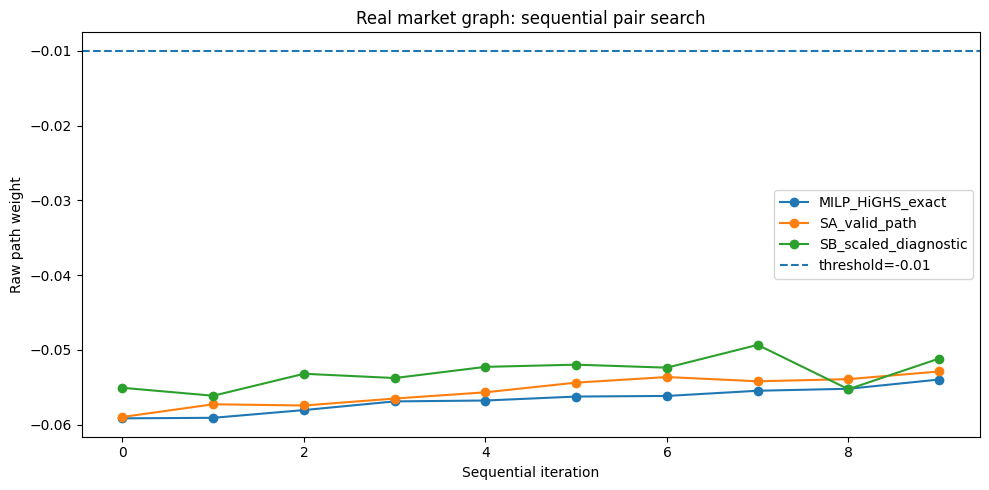

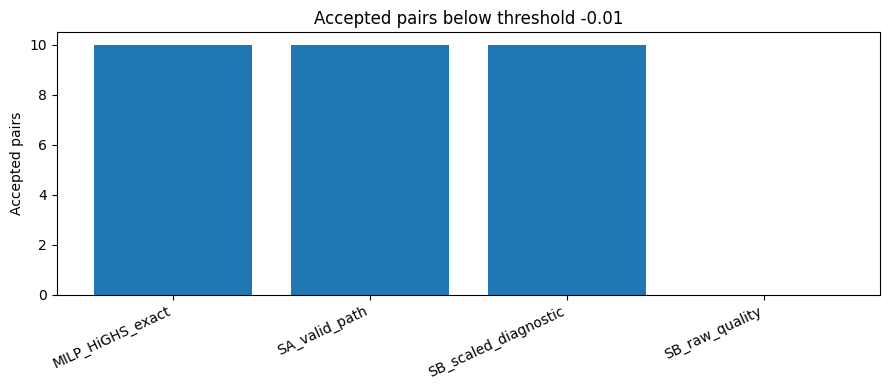

In [14]:
if len(analysis_df):
    plot_df = analysis_df.dropna(subset=["path_weight"]).copy()
    if len(plot_df):
        plt.figure(figsize=(10, 5))
        for solver, g in plot_df.groupby("solver"):
            plt.plot(g["iteration"], g["path_weight"], marker="o", label=solver)
        plt.axhline(THRESHOLD, linestyle="--", label=f"threshold={THRESHOLD}")
        plt.xlabel("Sequential iteration")
        plt.ylabel("Raw path weight")
        plt.title("Real market graph: sequential pair search")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT_DIR / "real_market_sequential_path_weights_04_05_02.png", dpi=160)
        plt.show()

if len(summary_df):
    plt.figure(figsize=(9, 4))
    plt.bar(summary_df["solver"], summary_df["n_accepted_pairs"])
    plt.ylabel("Accepted pairs")
    plt.title(f"Accepted pairs below threshold {THRESHOLD}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "real_market_accepted_pairs_by_solver_04_05_02.png", dpi=160)
    plt.show()

## 16. Список сохранённых артефактов

In [16]:
artifacts = sorted(p.name for p in OUT_DIR.glob("real_market_*_04_05_02.*"))
artifacts_df = pd.DataFrame({"artifact": artifacts})
artifacts_df.to_csv(OUT_DIR / "real_market_artifacts_04_05_02.csv", index=False)
display(artifacts_df)

,artifact
0,real_market_accepted_pairs_by_solver_04_05_02.png
1,real_market_artifacts_04_05_02.csv
2,real_market_endpoint_duplicates_04_05_02.csv
3,real_market_final_forbidden_pairs_04_05_02.csv
4,real_market_final_interpretation_04_05_02.txt
5,real_market_final_pairs_04_05_02.csv
6,real_market_final_solver_comparison_04_05_02.csv
7,real_market_final_solver_comparison_display_04...
8,real_market_interpretation_04_05_02.txt
9,real_market_multiple_pairs_04_05_02.csv


In [ ]:
# 04_05_02: TRUE SB TABU VERIFICATION
# Re-runs sequential SB from scratch with updated tabu matrix


from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
from IPython.display import display

for p in [Path("."), Path(".."), Path("/mnt/data")]:
    if str(p.resolve()) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

from qubo_cycle import build_cycle_qubo
from ising_mapping import qubo_to_ising
from pair_search import verify_single_dummy_cycle, extract_pair_and_weight
from SB_modules import BSB, DSB


TAG = "04_05_02"

# 1. Paths and config

def locate_file(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path("04_05") / filename,
        Path("../04_05") / filename,
        Path("/mnt/data/04_05") / filename,
        Path("/mnt/data") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Cannot find file:\n" + "\n".join(str(p) for p in candidates)
    )


if Path("04_05").exists():
    SAVE_DIR = Path("04_05")
elif Path.cwd().name == "04_05":
    SAVE_DIR = Path(".")
else:
    SAVE_DIR = Path(".")

SAVE_DIR.mkdir(exist_ok=True)

weights_path = locate_file("real_data_market_weights_04_05_01.csv")

THRESHOLD = -0.01

MC = 1.0
MP_RAW = 1.0
DT = 0.5
N_ITER = 500
N_RUNS = 100
MAX_PAIRS = 10
SB_VARIANT = "BSB"
BASE_SEED = 450502

print("SAVE_DIR:", SAVE_DIR.resolve())
print("weights:", weights_path)
print("threshold:", THRESHOLD)
print("SB mode:", SB_VARIANT, "dt:", DT, "n_iter:", N_ITER, "n_runs:", N_RUNS)

# 2. Load real market graph

w_df = pd.read_csv(weights_path, index_col=0)
symbols_with_dummy = list(w_df.index)
w_raw = w_df.to_numpy(dtype=float)

N = w_raw.shape[0] - 1

node_to_symbol = {i: s for i, s in enumerate(symbols_with_dummy)}

stock_block = w_raw[1:, 1:]
off_diag_mask = ~np.eye(N, dtype=bool)
max_abs_stock_weight = float(np.max(np.abs(stock_block[off_diag_mask])))

if max_abs_stock_weight <= 1e-15:
    COST_SCALE = 1.0
else:
    COST_SCALE = 1.0 / max_abs_stock_weight

print("N stock nodes:", N)
print("max_abs_stock_weight:", max_abs_stock_weight)
print("COST_SCALE:", COST_SCALE)


# 3. Helpers

def make_tabu_matrix(forbidden_pairs: set[tuple[int, int]]) -> np.ndarray:
    """
    forbidden_pairs stores human endpoints:
        (short, long)

    QUBO tabu convention:
        T[long, short] = 1
    """
    T = np.zeros_like(w_raw, dtype=int)
    for short, long in forbidden_pairs:
        T[long, short] = 1
    return T


def decode_edges(z: np.ndarray, var_map) -> list[tuple[int, int]]:
    z = np.asarray(z, dtype=int).reshape(-1)
    return [var_map.u2e[u] for u, bit in enumerate(z) if bit == 1]


def path_symbols_from_nodes(path_nodes: list[int]) -> str:
    return "->".join(node_to_symbol.get(i, str(i)) for i in path_nodes)


def cycle_to_str(cycle: list[int] | None) -> str:
    if cycle is None:
        return ""
    return "->".join(str(x) for x in cycle)


def run_solver_once(J, h, seed: int):
    if SB_VARIANT.upper() == "BSB":
        solver = BSB(J, h=h, n_iter=N_ITER, dt=DT, seed=seed)
    elif SB_VARIANT.upper() == "DSB":
        solver = DSB(J, h=h, n_iter=N_ITER, dt=DT, seed=seed)
    else:
        raise ValueError("SB_VARIANT must be BSB or DSB")

    solver.run(record_trajectory=False)

    x = solver.x.reshape(-1)
    s = np.where(x >= 0.0, 1, -1)
    z = ((s + 1) // 2).astype(int)
    return z


def run_sequential_sb_tabu_verification(
    mode_name: str,
    w_for_qubo: np.ndarray,
    mp: float,
    max_pairs: int = MAX_PAIRS,
    n_runs: int = N_RUNS,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    True sequential run:
    - At each iteration, rebuild QUBO with current tabu matrix T.
    - Run SB n_runs times.
    - Decode each SB output.
    - Check if valid endpoint is already tabu.
    - Accept only non-tabu valid cycle below raw threshold.
    """
    forbidden_pairs: set[tuple[int, int]] = set()

    run_rows = []
    accepted_rows = []
    stop_rows = []

    t_mode_start = time.perf_counter()

    for iteration in range(max_pairs):
        T = make_tabu_matrix(forbidden_pairs)

        lin, quad, var_map = build_cycle_qubo(
            w=w_for_qubo,
            tabu=T,
            mc=MC,
            mp=mp,
        )

        J, h, _ = qubo_to_ising(lin, quad)

        iteration_rows = []
        iter_start = time.perf_counter()

        for r in range(n_runs):
            seed = BASE_SEED + 100000 * iteration + r

            t0 = time.perf_counter()
            z = run_solver_once(J, h, seed=seed)
            runtime = time.perf_counter() - t0

            selected_edges = decode_edges(z, var_map)
            ok, cycle = verify_single_dummy_cycle(selected_edges, N=N)

            row = {
                "mode": mode_name,
                "iteration": iteration,
                "run": r,
                "seed": seed,
                "mp": mp,
                "cost_scale": float(COST_SCALE if mode_name != "SB_raw_quality" else 1.0),
                "n_tabu_before": len(forbidden_pairs),
                "n_selected_edges": len(selected_edges),
                "valid_cycle": bool(ok),
                "cycle_nodes": cycle_to_str(cycle),
                "edges_selected": ";".join(f"{a}->{b}" for a, b in selected_edges),
                "short_node": np.nan,
                "long_node": np.nan,
                "short_symbol": np.nan,
                "long_symbol": np.nan,
                "path_nodes": np.nan,
                "path_symbols": np.nan,
                "path_length_assets": 0,
                "path_weight_raw": np.nan,
                "path_weight_qubo": np.nan,
                "direct_weight_raw": np.nan,
                "endpoint_in_tabu_before": False,
                "below_threshold_raw": False,
                "eligible_after_hard_filter": False,
                "runtime_sec": runtime,
            }

            if ok:
                short, long, path_nodes, path_weight_raw = extract_pair_and_weight(
                    cycle,
                    w_raw,
                )
                _, _, _, path_weight_qubo = extract_pair_and_weight(
                    cycle,
                    w_for_qubo,
                )

                endpoint_in_tabu_before = bool(T[long, short] == 1)
                below_threshold_raw = bool(path_weight_raw < THRESHOLD)
                eligible = (
                    (not endpoint_in_tabu_before)
                    and below_threshold_raw
                    and short != long
                )

                row.update({
                    "short_node": int(short),
                    "long_node": int(long),
                    "short_symbol": node_to_symbol.get(short, str(short)),
                    "long_symbol": node_to_symbol.get(long, str(long)),
                    "path_nodes": "->".join(str(x) for x in path_nodes),
                    "path_symbols": path_symbols_from_nodes(path_nodes),
                    "path_length_assets": len(path_nodes),
                    "path_weight_raw": float(path_weight_raw),
                    "path_weight_qubo": float(path_weight_qubo),
                    "direct_weight_raw": float(w_raw[short, long]),
                    "endpoint_in_tabu_before": endpoint_in_tabu_before,
                    "below_threshold_raw": below_threshold_raw,
                    "eligible_after_hard_filter": eligible,
                })

            iteration_rows.append(row)
            run_rows.append(row)

        iter_df = pd.DataFrame(iteration_rows)

        valid_cycle_rate = float(iter_df["valid_cycle"].mean())
        nonzero_edge_rate = float((iter_df["n_selected_edges"] > 0).mean())

        valid_df = iter_df[iter_df["valid_cycle"] == True].copy()
        if len(valid_df) > 0:
            tabu_violation_rate_among_valid = float(
                valid_df["endpoint_in_tabu_before"].mean()
            )
        else:
            tabu_violation_rate_among_valid = np.nan

        candidates = iter_df[
            iter_df["eligible_after_hard_filter"] == True
        ].copy()

        if candidates.empty:
            stop_rows.append({
                "mode": mode_name,
                "iteration": iteration,
                "status": "stop_no_non_tabu_valid_cycle_below_threshold",
                "accepted": False,
                "n_tabu_before": len(forbidden_pairs),
                "valid_cycle_rate": valid_cycle_rate,
                "nonzero_edge_rate": nonzero_edge_rate,
                "tabu_violation_rate_among_valid": tabu_violation_rate_among_valid,
                "threshold": THRESHOLD,
                "iteration_runtime_sec": time.perf_counter() - iter_start,
            })
            break

        best = candidates.sort_values(
            ["path_weight_raw", "run"],
            ascending=[True, True],
        ).iloc[0]

        short = int(best["short_node"])
        long = int(best["long_node"])

        accepted_row = {
            "mode": mode_name,
            "iteration": iteration,
            "status": "ok",
            "accepted": True,
            "chosen_run": int(best["run"]),
            "chosen_seed": int(best["seed"]),
            "short_node": short,
            "long_node": long,
            "short_symbol": best["short_symbol"],
            "long_symbol": best["long_symbol"],
            "path_nodes": best["path_nodes"],
            "path_symbols": best["path_symbols"],
            "path_length_assets": int(best["path_length_assets"]),
            "path_weight": float(best["path_weight_raw"]),
            "path_weight_qubo": float(best["path_weight_qubo"]),
            "direct_weight": float(best["direct_weight_raw"]),
            "is_bypass": bool(int(best["path_length_assets"]) > 2),
            "threshold": THRESHOLD,
            "n_tabu_before": len(forbidden_pairs),
            "valid_cycle_rate": valid_cycle_rate,
            "nonzero_edge_rate": nonzero_edge_rate,
            "tabu_violation_rate_among_valid": tabu_violation_rate_among_valid,
            "mp": mp,
            "cost_scale": float(COST_SCALE if mode_name != "SB_raw_quality" else 1.0),
            "iteration_runtime_sec": time.perf_counter() - iter_start,
        }

        accepted_rows.append(accepted_row)

        # Update tabu AFTER accepting the pair.
        forbidden_pairs.add((short, long))

    run_df = pd.DataFrame(run_rows)
    accepted_df = pd.DataFrame(accepted_rows)
    stop_df = pd.DataFrame(stop_rows)

    print(
        f"{mode_name}: accepted={len(accepted_df)}, "
        f"runtime={time.perf_counter() - t_mode_start:.2f}s"
    )

    return run_df, accepted_df, stop_df


# 4. Run three diagnostic SB modes

modes = [
    {
        "mode_name": "SB_raw_quality",
        "w_for_qubo": w_raw.copy(),
        "mp": 1.0,
    },
    {
        "mode_name": "SB_scaled_fixed_mp",
        "w_for_qubo": w_raw * COST_SCALE,
        "mp": 1.0,
    },
    {
        "mode_name": "SB_scaled_scaled_mp",
        "w_for_qubo": w_raw * COST_SCALE,
        "mp": COST_SCALE,
    },
]

all_runs = []
all_pairs = []
all_stops = []

for cfg in modes:
    run_df, pair_df, stop_df = run_sequential_sb_tabu_verification(**cfg)
    all_runs.append(run_df)
    all_pairs.append(pair_df)
    all_stops.append(stop_df)

runs_df = pd.concat(all_runs, ignore_index=True, sort=False)
pairs_df = pd.concat(all_pairs, ignore_index=True, sort=False)
stops_df = pd.concat(all_stops, ignore_index=True, sort=False)


# 5. Tabu violation diagnostics

violations_df = runs_df[
    (runs_df["valid_cycle"] == True)
    & (runs_df["endpoint_in_tabu_before"] == True)
].copy()

accepted = pairs_df[pairs_df["accepted"] == True].copy()

if len(accepted):
    endpoint_counts = (
        accepted
        .groupby(["mode", "short_symbol", "long_symbol"], dropna=False)
        .size()
        .reset_index(name="count")
    )
    endpoint_duplicates = endpoint_counts[endpoint_counts["count"] > 1].copy()
else:
    endpoint_duplicates = pd.DataFrame(
        columns=["mode", "short_symbol", "long_symbol", "count"]
    )


# 6. Build final tabu matrices from accepted pairs

def build_final_tabu_matrix_for_mode(mode_name: str) -> pd.DataFrame:
    T = np.zeros_like(w_raw, dtype=int)

    sub = pairs_df[
        (pairs_df["mode"] == mode_name)
        & (pairs_df["accepted"] == True)
    ].copy()

    for _, r in sub.iterrows():
        short = int(r["short_node"])
        long = int(r["long_node"])
        T[long, short] = 1

    return pd.DataFrame(
        T,
        index=symbols_with_dummy,
        columns=symbols_with_dummy,
    )


tabu_matrices = {}
for cfg in modes:
    mode_name = cfg["mode_name"]
    T_df = build_final_tabu_matrix_for_mode(mode_name)
    tabu_matrices[mode_name] = T_df
    T_df.to_csv(SAVE_DIR / f"real_market_tabu_matrix_{mode_name}_{TAG}.csv")


# 7. Summary

summary_rows = []

for cfg in modes:
    mode_name = cfg["mode_name"]

    sub_runs = runs_df[runs_df["mode"] == mode_name].copy()
    sub_pairs = pairs_df[
        (pairs_df["mode"] == mode_name)
        & (pairs_df["accepted"] == True)
    ].copy()
    sub_viol = violations_df[violations_df["mode"] == mode_name].copy()
    sub_dup = endpoint_duplicates[endpoint_duplicates["mode"] == mode_name].copy()

    n_runs_total = len(sub_runs)
    n_valid = int(sub_runs["valid_cycle"].sum()) if n_runs_total else 0
    n_eligible = int(sub_runs["eligible_after_hard_filter"].sum()) if n_runs_total else 0

    summary_rows.append({
        "mode": mode_name,
        "mp": cfg["mp"],
        "cost_scale": float(COST_SCALE if mode_name != "SB_raw_quality" else 1.0),
        "n_runs_total": n_runs_total,
        "n_valid_cycles": n_valid,
        "valid_cycle_rate": n_valid / n_runs_total if n_runs_total else np.nan,
        "n_valid_tabu_violations": len(sub_viol),
        "tabu_violation_rate_among_all_runs": len(sub_viol) / n_runs_total if n_runs_total else np.nan,
        "tabu_violation_rate_among_valid_cycles": len(sub_viol) / n_valid if n_valid else np.nan,
        "n_eligible_after_hard_filter": n_eligible,
        "n_accepted_pairs": len(sub_pairs),
        "duplicate_accepted_endpoint_pairs": len(sub_dup),
        "best_path_weight": float(sub_pairs["path_weight"].min()) if len(sub_pairs) else np.nan,
        "mean_path_weight": float(sub_pairs["path_weight"].mean()) if len(sub_pairs) else np.nan,
        "n_bypass": int(sub_pairs["is_bypass"].sum()) if len(sub_pairs) else 0,
        "final_tabu_nonzero_entries": int(tabu_matrices[mode_name].to_numpy().sum()),
        "threshold": THRESHOLD,
    })

summary_df = pd.DataFrame(summary_rows)

# 8. Save outputs

runs_df.to_csv(
    SAVE_DIR / f"real_market_sb_tabu_verification_runs_{TAG}.csv",
    index=False,
)

pairs_df.to_csv(
    SAVE_DIR / f"real_market_sb_tabu_verification_pairs_{TAG}.csv",
    index=False,
)

violations_df.to_csv(
    SAVE_DIR / f"real_market_sb_tabu_violations_{TAG}.csv",
    index=False,
)

summary_df.to_csv(
    SAVE_DIR / f"real_market_sb_tabu_summary_{TAG}.csv",
    index=False,
)

stops_df.to_csv(
    SAVE_DIR / f"real_market_sb_tabu_stops_{TAG}.csv",
    index=False,
)

endpoint_duplicates.to_csv(
    SAVE_DIR / f"real_market_sb_tabu_endpoint_duplicates_{TAG}.csv",
    index=False,
)

# 9. Display sanity checks

print("\nSaved files:")
print(SAVE_DIR / f"real_market_sb_tabu_verification_runs_{TAG}.csv")
print(SAVE_DIR / f"real_market_sb_tabu_verification_pairs_{TAG}.csv")
print(SAVE_DIR / f"real_market_sb_tabu_violations_{TAG}.csv")
print(SAVE_DIR / f"real_market_sb_tabu_summary_{TAG}.csv")
print(SAVE_DIR / f"real_market_sb_tabu_stops_{TAG}.csv")
print(SAVE_DIR / f"real_market_sb_tabu_endpoint_duplicates_{TAG}.csv")

print("\nSummary:")
display(summary_df)

print("\nAccepted endpoint duplicates:")
if len(endpoint_duplicates) == 0:
    print("none")
else:
    display(endpoint_duplicates)

print("\nTabu violations returned by SB before hard filter:")
if len(violations_df) == 0:
    print("none")
else:
    display(
        violations_df[
            [
                "mode",
                "iteration",
                "run",
                "short_symbol",
                "long_symbol",
                "path_weight_raw",
                "path_symbols",
                "n_tabu_before",
            ]
        ].head(20)
    )

print("\nFinal tabu nonzero entries by mode:")
for mode_name, T_df in tabu_matrices.items():
    print(mode_name, int(T_df.to_numpy().sum()))

SAVE_DIR: C:\Users\Антон\Desktop\курсовая\04_05
weights: 04_05\real_data_market_weights_04_05_01.csv
threshold: -0.01
SB mode: BSB dt: 0.5 n_iter: 500 n_runs: 100
N stock nodes: 15
max_abs_stock_weight: 0.0269822518707688
COST_SCALE: 37.06139890730726
SB_raw_quality: accepted=0, runtime=2.15s
SB_scaled_fixed_mp: accepted=10, runtime=21.66s
SB_scaled_scaled_mp: accepted=0, runtime=2.20s

Saved files:
04_05\real_market_sb_tabu_verification_runs_04_05_02.csv
04_05\real_market_sb_tabu_verification_pairs_04_05_02.csv
04_05\real_market_sb_tabu_violations_04_05_02.csv
04_05\real_market_sb_tabu_summary_04_05_02.csv
04_05\real_market_sb_tabu_stops_04_05_02.csv
04_05\real_market_sb_tabu_endpoint_duplicates_04_05_02.csv

Summary:


,mode,mp,cost_scale,n_runs_total,n_valid_cycles,valid_cycle_rate,n_valid_tabu_violations,tabu_violation_rate_among_all_runs,tabu_violation_rate_among_valid_cycles,n_eligible_after_hard_filter,n_accepted_pairs,duplicate_accepted_endpoint_pairs,best_path_weight,mean_path_weight,n_bypass,final_tabu_nonzero_entries,threshold
0,SB_raw_quality,1.000000,1.000000,100,0,0.00,0,0.00,NaN,0,0,0,NaN,NaN,0,0,-0.01
1,SB_scaled_fixed_mp,1.000000,37.061399,1000,390,0.39,10,0.01,0.025641,380,10,0,-0.054173,-0.051157,10,10,-0.01
2,SB_scaled_scaled_mp,37.061399,37.061399,100,0,0.00,0,0.00,NaN,0,0,0,NaN,NaN,0,0,-0.01



Accepted endpoint duplicates:
none

Tabu violations returned by SB before hard filter:


,mode,iteration,run,short_symbol,long_symbol,path_weight_raw,path_symbols,n_tabu_before
429,SB_scaled_fixed_mp,3,29,ATOMUSDT,SOLUSDT,-0.051100,ATOMUSDT->ETHUSDT->BCHUSDT->LTCUSDT->SOLUSDT,3
655,SB_scaled_fixed_mp,5,55,ATOMUSDT,BTCUSDT,-0.049595,ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->BTCUSDT,5
702,SB_scaled_fixed_mp,6,2,ATOMUSDT,XRPUSDT,-0.051529,ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->XRPUSDT,6
826,SB_scaled_fixed_mp,7,26,ATOMUSDT,BTCUSDT,-0.049213,ATOMUSDT->XRPUSDT->BCHUSDT->LTCUSDT->BTCUSDT,7
875,SB_scaled_fixed_mp,7,75,ATOMUSDT,SOLUSDT,-0.051964,ATOMUSDT->DOGEUSDT->ETHUSDT->BCHUSDT->LTCUSDT-...,7
925,SB_scaled_fixed_mp,8,25,ATOMUSDT,XRPUSDT,-0.051529,ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->XRPUSDT,8
944,SB_scaled_fixed_mp,8,44,LTCUSDT,SOLUSDT,-0.047684,LTCUSDT->ETHUSDT->BCHUSDT->ATOMUSDT->SOLUSDT,8
959,SB_scaled_fixed_mp,8,59,ATOMUSDT,XRPUSDT,-0.051529,ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->XRPUSDT,8
1080,SB_scaled_fixed_mp,9,80,ATOMUSDT,XRPUSDT,-0.051529,ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->XRPUSDT,9
1089,SB_scaled_fixed_mp,9,89,ATOMUSDT,BTCUSDT,-0.049595,ATOMUSDT->SOLUSDT->BCHUSDT->LTCUSDT->BTCUSDT,9



Final tabu nonzero entries by mode:
SB_raw_quality 0
SB_scaled_fixed_mp 10
SB_scaled_scaled_mp 0


QUBO-tabu penalty снижает вероятность повторов, но не гарантирует их полное отсутствие в эвристическом SB-решении; поэтому hard endpoint post-filter остаётся необходимым.

Это хороший экспериментальный результат:

SB_raw_quality на real weights не нашёл валидных dummy-cycles.
SB_scaled_fixed_mp показал, что SB способен находить осмысленные пары после усиления cost-сигнала.
При этом QUBO-tabu penalty не является строгой гарантией для эвристического SB-решения.
Поэтому sequential multiple-pair search должен включать два уровня защиты:
tabu penalty внутри QUBO;
deterministic hard endpoint filter после декодирования.

SB_scaled_scaled_mp можно упомянуть только как diagnostic: одновременное масштабирование cost и penalty не улучшило поиск в текущей Python/SB-динамике.

In [ ]:
# 04_05_02: FINAL REAL-MARKET SOLVER COMPARISON
# Aggregates MILP, SA, SB raw, and SB scaled diagnostics

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

TAG = "04_05_02"

# Important: economic threshold is fixed manually.
# Do NOT read the first row from threshold diagnostics.
THRESHOLD = -0.01

# 1. Paths

if Path("04_05").exists():
    SAVE_DIR = Path("04_05")
elif Path.cwd().name == "04_05":
    SAVE_DIR = Path(".")
else:
    SAVE_DIR = Path(".")

SAVE_DIR.mkdir(exist_ok=True)


def locate_file(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path("04_05") / filename,
        Path("../04_05") / filename,
        Path("/mnt/data") / filename,
        Path("/mnt/data/04_05") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Cannot find file:\n" + "\n".join(str(p) for p in candidates)
    )


def safe_read_csv(filename: str) -> pd.DataFrame:
    path = locate_file(filename)
    print("Loaded:", path)
    return pd.read_csv(path)

# 2. Load source tables

multi_df = safe_read_csv(f"real_market_multiple_pairs_{TAG}.csv")

sb_summary_df = safe_read_csv(f"real_market_sb_tabu_summary_{TAG}.csv")
sb_pairs_df = safe_read_csv(f"real_market_sb_tabu_verification_pairs_{TAG}.csv")
sb_viol_df = safe_read_csv(f"real_market_sb_tabu_violations_{TAG}.csv")

threshold_diag_df = safe_read_csv(f"real_market_threshold_diagnostics_{TAG}.csv")

# 3. Helpers

def bool_series(s: pd.Series) -> pd.Series:
    """
    Robust conversion for bool columns saved as bool / string / int.
    """
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "yes"])


def summarize_pair_table(
    df: pd.DataFrame,
    solver_col: str,
    solver_name: str,
    label: str,
    solver_type: str,
    diagnostic: bool = False,
) -> dict:
    """
    Summarize accepted pairs for one solver/mode.
    """
    if df is None or df.empty or solver_col not in df.columns:
        sub = pd.DataFrame()
    else:
        sub = df[df[solver_col] == solver_name].copy()

    if len(sub) and "accepted" in sub.columns:
        sub = sub[bool_series(sub["accepted"])].copy()

    # Always check economic threshold on raw path_weight.
    if len(sub) and "path_weight" in sub.columns:
        sub = sub[sub["path_weight"] < THRESHOLD].copy()

    # Duplicate endpoint diagnostics.
    duplicate_endpoint_pairs = 0
    if len(sub) and {"short_node", "long_node"}.issubset(sub.columns):
        endpoint_counts = sub.groupby(
            ["short_node", "long_node"],
            dropna=False,
        ).size()
        duplicate_endpoint_pairs = int((endpoint_counts > 1).sum())

    # Bypass diagnostics.
    n_bypass = 0
    if len(sub) and "is_bypass" in sub.columns:
        n_bypass = int(bool_series(sub["is_bypass"]).sum())

    # Runtime if available.
    runtime_sec_total = np.nan
    if len(sub) and "runtime_sec" in sub.columns and sub["runtime_sec"].notna().any():
        runtime_sec_total = float(sub["runtime_sec"].fillna(0.0).sum())
    elif len(sub) and "iteration_runtime_sec" in sub.columns and sub["iteration_runtime_sec"].notna().any():
        runtime_sec_total = float(sub["iteration_runtime_sec"].fillna(0.0).sum())

    return {
        "solver": label,
        "source_solver_name": solver_name,
        "solver_type": solver_type,
        "diagnostic_mode": bool(diagnostic),
        "threshold": THRESHOLD,
        "n_accepted_pairs": int(len(sub)),
        "best_path_weight": float(sub["path_weight"].min()) if len(sub) else np.nan,
        "mean_path_weight": float(sub["path_weight"].mean()) if len(sub) else np.nan,
        "median_path_weight": float(sub["path_weight"].median()) if len(sub) else np.nan,
        "n_bypass": n_bypass,
        "bypass_share": float(n_bypass / len(sub)) if len(sub) else np.nan,
        "duplicate_endpoint_pairs": duplicate_endpoint_pairs,
        "runtime_sec_total": runtime_sec_total,
    }

# 4. Build final solver summary

rows = []

# Exact and classical baselines.
rows.append(
    summarize_pair_table(
        multi_df,
        solver_col="solver",
        solver_name="MILP_HiGHS_exact",
        label="MILP / HiGHS exact",
        solver_type="exact baseline",
        diagnostic=False,
    )
)

rows.append(
    summarize_pair_table(
        multi_df,
        solver_col="solver",
        solver_name="SA_valid_path",
        label="Simulated annealing",
        solver_type="classical heuristic",
        diagnostic=False,
    )
)

# SB true tabu verification modes.
sb_modes = [
    ("SB_raw_quality", "SB raw quality mode", False),
    ("SB_scaled_fixed_mp", "SB scaled diagnostic, fixed mp", True),
    ("SB_scaled_scaled_mp", "SB scaled diagnostic, scaled mp", True),
]

for mode_name, label, diagnostic in sb_modes:
    row = summarize_pair_table(
        sb_pairs_df,
        solver_col="mode",
        solver_name=mode_name,
        label=label,
        solver_type="quantum-inspired SB",
        diagnostic=diagnostic,
    )

    # Add SB-specific diagnostics from true tabu verification summary.
    srow = sb_summary_df[sb_summary_df["mode"] == mode_name]

    if len(srow):
        srow = srow.iloc[0]
        for col in [
            "mp",
            "cost_scale",
            "n_runs_total",
            "n_valid_cycles",
            "valid_cycle_rate",
            "n_valid_tabu_violations",
            "tabu_violation_rate_among_valid_cycles",
            "n_eligible_after_hard_filter",
            "final_tabu_nonzero_entries",
        ]:
            if col in sb_summary_df.columns:
                row[col] = srow[col]
    else:
        row.update({
            "mp": np.nan,
            "cost_scale": np.nan,
            "n_runs_total": np.nan,
            "n_valid_cycles": np.nan,
            "valid_cycle_rate": np.nan,
            "n_valid_tabu_violations": np.nan,
            "tabu_violation_rate_among_valid_cycles": np.nan,
            "n_eligible_after_hard_filter": np.nan,
            "final_tabu_nonzero_entries": np.nan,
        })

    rows.append(row)

summary = pd.DataFrame(rows)

# 5. Gap to MILP exact baseline

milp_best_series = summary.loc[
    summary["source_solver_name"] == "MILP_HiGHS_exact",
    "best_path_weight",
]

milp_best = (
    float(milp_best_series.iloc[0])
    if len(milp_best_series) and pd.notna(milp_best_series.iloc[0])
    else np.nan
)

summary["gap_to_milp_best"] = summary["best_path_weight"] - milp_best

if pd.notna(milp_best) and abs(milp_best) > 1e-15:
    summary["relative_gap_to_milp_abs"] = summary["gap_to_milp_best"] / abs(milp_best)
else:
    summary["relative_gap_to_milp_abs"] = np.nan

# 6. Add threshold diagnostics

thr_row = threshold_diag_df[
    np.isclose(threshold_diag_df["threshold"].astype(float), THRESHOLD)
]

if len(thr_row):
    summary["n_direct_edges_below_threshold"] = int(
        thr_row["n_direct_edges_below_threshold"].iloc[0]
    )
    summary["share_direct_edges_below_threshold"] = float(
        thr_row["share_direct_edges_below_threshold"].iloc[0]
    )
else:
    summary["n_direct_edges_below_threshold"] = np.nan
    summary["share_direct_edges_below_threshold"] = np.nan

display_cols = [
    "solver",
    "solver_type",
    "diagnostic_mode",
    "n_accepted_pairs",
    "best_path_weight",
    "gap_to_milp_best",
    "mean_path_weight",
    "n_bypass",
    "bypass_share",
    "duplicate_endpoint_pairs",
    "valid_cycle_rate",
    "n_valid_tabu_violations",
    "tabu_violation_rate_among_valid_cycles",
    "final_tabu_nonzero_entries",
    "runtime_sec_total",
    "threshold",
]

display_df = summary[[c for c in display_cols if c in summary.columns]].copy()

for col in display_df.select_dtypes(include=[float]).columns:
    display_df[col] = display_df[col].round(6)

# 8. Build final accepted pairs table

pair_frames = []

# MILP and SA pairs.
for solver_name, label in [
    ("MILP_HiGHS_exact", "MILP / HiGHS exact"),
    ("SA_valid_path", "Simulated annealing"),
]:
    sub = multi_df[
        (multi_df["solver"] == solver_name)
        & bool_series(multi_df["accepted"])
    ].copy()

    sub = sub[sub["path_weight"] < THRESHOLD].copy()

    if len(sub):
        sub["solver_display"] = label
        sub["diagnostic_mode"] = False
        pair_frames.append(sub)


# SB pairs.
for mode_name, label, diagnostic in sb_modes:
    sub = sb_pairs_df[
        (sb_pairs_df["mode"] == mode_name)
        & bool_series(sb_pairs_df["accepted"])
    ].copy()

    sub = sub[sub["path_weight"] < THRESHOLD].copy()

    if len(sub):
        sub = sub.rename(columns={"mode": "solver"})
        sub["solver_display"] = label
        sub["diagnostic_mode"] = diagnostic
        pair_frames.append(sub)


if pair_frames:
    pairs_all = pd.concat(pair_frames, ignore_index=True, sort=False)

    keep_cols = [
        "solver_display",
        "diagnostic_mode",
        "iteration",
        "short_symbol",
        "long_symbol",
        "path_symbols",
        "path_length_assets",
        "path_weight",
        "direct_weight",
        "is_bypass",
        "threshold",
    ]

    pairs_all = pairs_all[[c for c in keep_cols if c in pairs_all.columns]].copy()
    pairs_all = pairs_all.sort_values(
        ["solver_display", "path_weight"],
        ascending=[True, True],
    )
else:
    pairs_all = pd.DataFrame()

lines = []

lines.append("Финальная сводка по эксперименту 4.5.2 на реальных рыночных данных.")
lines.append(f"Экономический threshold зафиксирован как {THRESHOLD}.")

if len(thr_row):
    lines.append(
        "На уровне прямых directed edges ниже threshold находятся "
        f"{int(thr_row['n_direct_edges_below_threshold'].iloc[0])} ребер "
        f"({float(thr_row['share_direct_edges_below_threshold'].iloc[0]):.2%} "
        "от всех stock-edges)."
    )

if pd.notna(milp_best):
    lines.append(
        f"MILP / HiGHS используется как exact baseline; "
        f"лучший найденный вес равен {milp_best:.6f}."
    )


def get_val(src: str, col: str):
    x = summary.loc[summary["source_solver_name"] == src, col]
    return x.iloc[0] if len(x) else np.nan


lines.append(
    f"MILP / HiGHS принял "
    f"{int(get_val('MILP_HiGHS_exact', 'n_accepted_pairs'))} пар; "
    f"SA принял {int(get_val('SA_valid_path', 'n_accepted_pairs'))} пар."
)

raw_vcr = get_val("SB_raw_quality", "valid_cycle_rate")
lines.append(
    f"SB raw quality mode принял "
    f"{int(get_val('SB_raw_quality', 'n_accepted_pairs'))} пар "
    f"и имел valid-cycle rate {raw_vcr if pd.notna(raw_vcr) else np.nan}."
)

lines.append(
    f"SB scaled diagnostic с fixed mp принял "
    f"{int(get_val('SB_scaled_fixed_mp', 'n_accepted_pairs'))} пар; "
    "этот режим является диагностическим, поскольку меняет масштаб "
    "cost-сигнала относительно исходной QUBO-задачи."
)

viol = get_val("SB_scaled_fixed_mp", "n_valid_tabu_violations")
if pd.notna(viol):
    lines.append(
        f"В SB scaled diagnostic обнаружено {int(viol)} валидных tabu-нарушений "
        "до hard-filter; это подтверждает необходимость deterministic endpoint "
        "post-filter после декодирования SB."
    )

lines.append(
    "Итоговая интерпретация: наличие торговых кандидатов подтверждается MILP и SA, "
    "а неудача raw SB связана с численной и ландшафтной чувствительностью "
    "constrained QUBO/SB на real weights. Это согласуется с ранее установленной "
    "необходимостью post-verification, hard endpoint filter и калибровки penalty terms."
)

interpretation_text = "\n".join(lines)


# 10. Save final outputs

summary_path = SAVE_DIR / f"real_market_final_solver_comparison_{TAG}.csv"
display_path = SAVE_DIR / f"real_market_final_solver_comparison_display_{TAG}.csv"
pairs_path = SAVE_DIR / f"real_market_final_pairs_{TAG}.csv"
text_path = SAVE_DIR / f"real_market_final_interpretation_{TAG}.txt"

summary.to_csv(summary_path, index=False)
display_df.to_csv(display_path, index=False)
pairs_all.to_csv(pairs_path, index=False)
text_path.write_text(interpretation_text, encoding="utf-8")


# 11. Display

print("\nSaved final 4.5.2 files:")
print(summary_path)
print(display_path)
print(pairs_path)
print(text_path)

print("\nFinal solver comparison:")
display(display_df)

print("\nFinal accepted pairs:")
display(pairs_all.head(30))

print("\nInterpretation text:")
print(interpretation_text)

Loaded: 04_05\real_market_multiple_pairs_04_05_02.csv
Loaded: 04_05\real_market_sb_tabu_summary_04_05_02.csv
Loaded: 04_05\real_market_sb_tabu_verification_pairs_04_05_02.csv
Loaded: 04_05\real_market_sb_tabu_violations_04_05_02.csv
Loaded: 04_05\real_market_threshold_diagnostics_04_05_02.csv

Saved final 4.5.2 files:
04_05\real_market_final_solver_comparison_04_05_02.csv
04_05\real_market_final_solver_comparison_display_04_05_02.csv
04_05\real_market_final_pairs_04_05_02.csv
04_05\real_market_final_interpretation_04_05_02.txt

Final solver comparison:


,solver,solver_type,diagnostic_mode,n_accepted_pairs,best_path_weight,gap_to_milp_best,mean_path_weight,n_bypass,bypass_share,duplicate_endpoint_pairs,valid_cycle_rate,n_valid_tabu_violations,tabu_violation_rate_among_valid_cycles,final_tabu_nonzero_entries,runtime_sec_total,threshold
0,MILP / HiGHS exact,exact baseline,False,10,-0.059141,0.000000,-0.056685,10,1.0,0,NaN,NaN,NaN,NaN,1.113511,-0.01
1,Simulated annealing,classical heuristic,False,10,-0.058957,0.000184,-0.055475,10,1.0,0,NaN,NaN,NaN,NaN,18.593826,-0.01
2,SB raw quality mode,quantum-inspired SB,False,0,NaN,NaN,NaN,0,NaN,0,0.00,0.0,NaN,0.0,NaN,-0.01
3,"SB scaled diagnostic, fixed mp",quantum-inspired SB,True,10,-0.054173,0.004968,-0.051157,10,1.0,0,0.39,10.0,0.025641,10.0,21.477826,-0.01
4,"SB scaled diagnostic, scaled mp",quantum-inspired SB,True,0,NaN,NaN,NaN,0,NaN,0,0.00,0.0,NaN,0.0,NaN,-0.01



Final accepted pairs:


,solver_display,diagnostic_mode,iteration,short_symbol,long_symbol,path_symbols,path_length_assets,path_weight,direct_weight,is_bypass,threshold
0,MILP / HiGHS exact,False,0,ATOMUSDT,XRPUSDT,ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->...,11,-0.059141,-0.024296,True,-0.01
1,MILP / HiGHS exact,False,1,ATOMUSDT,ETHUSDT,ATOMUSDT->SOLUSDT->TRXUSDT->ETCUSDT->LINKUSDT-...,14,-0.059070,-0.024273,True,-0.01
2,MILP / HiGHS exact,False,2,ATOMUSDT,SOLUSDT,ATOMUSDT->XRPUSDT->AVAXUSDT->TRXUSDT->BTCUSDT-...,12,-0.058035,-0.024776,True,-0.01
3,MILP / HiGHS exact,False,3,LTCUSDT,ETHUSDT,LTCUSDT->XRPUSDT->BCHUSDT->ATOMUSDT->SOLUSDT->...,11,-0.056876,-0.025010,True,-0.01
4,MILP / HiGHS exact,False,4,LTCUSDT,XRPUSDT,LTCUSDT->BTCUSDT->ADAUSDT->DOGEUSDT->ETHUSDT->...,14,-0.056758,-0.026643,True,-0.01
5,MILP / HiGHS exact,False,5,LTCUSDT,SOLUSDT,LTCUSDT->XRPUSDT->AVAXUSDT->TRXUSDT->BTCUSDT->...,12,-0.056228,-0.026641,True,-0.01
6,MILP / HiGHS exact,False,6,ATOMUSDT,BTCUSDT,ATOMUSDT->SOLUSDT->TRXUSDT->ETCUSDT->LINKUSDT-...,14,-0.056147,-0.018989,True,-0.01
7,MILP / HiGHS exact,False,7,ATOMUSDT,AVAXUSDT,ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->...,12,-0.055453,-0.015265,True,-0.01
8,MILP / HiGHS exact,False,8,ATOMUSDT,LINKUSDT,ATOMUSDT->SOLUSDT->TRXUSDT->BTCUSDT->ADAUSDT->...,13,-0.055188,-0.019093,True,-0.01
9,MILP / HiGHS exact,False,9,LTCUSDT,BTCUSDT,LTCUSDT->XRPUSDT->ADAUSDT->BNBUSDT->DOGEUSDT->...,11,-0.053953,-0.024708,True,-0.01



Interpretation text:
Финальная сводка по эксперименту 4.5.2 на реальных рыночных данных.
Экономический threshold зафиксирован как -0.01.
На уровне прямых directed edges ниже threshold находятся 25 ребер (11.90% от всех stock-edges).
MILP / HiGHS используется как exact baseline; лучший найденный вес равен -0.059141.
MILP / HiGHS принял 10 пар; SA принял 10 пар.
SB raw quality mode принял 0 пар и имел valid-cycle rate 0.0.
SB scaled diagnostic с fixed mp принял 10 пар; этот режим является диагностическим, поскольку меняет масштаб cost-сигнала относительно исходной QUBO-задачи.
В SB scaled diagnostic обнаружено 10 валидных tabu-нарушений до hard-filter; это подтверждает необходимость deterministic endpoint post-filter после декодирования SB.
Итоговая интерпретация: наличие торговых кандидатов подтверждается MILP и SA, а неудача raw SB связана с численной и ландшафтной чувствительностью constrained QUBO/SB на real weights. Это согласуется с ранее установленной необходимостью post-verifica